# Variational inference: when approximation replaces sampling

**Companion to:** `bayes_29_07_2026.tex`, §*Variational inference: turning inference
into optimisation* (`sec:bayes-computational-history`).

## Historical context

MCMC approaches a posterior through repeated random sampling — the previous three
notebooks. The chapter describes a different strategy: choose a simple, tractable
family of distributions, and use **optimisation** to find the member of that family
closest to the true posterior:

> Jordan, M. I., Ghahramani, Z., Jaakkola, T. S., & Saul, L. K. (1999). *An
> Introduction to Variational Methods for Graphical Models*. Machine Learning, 37(2),
> 183–233.

> Blei, D. M., Kucukelbir, A., & McAuliffe, J. D. (2017). *Variational Inference: A
> Review for Statisticians*. Journal of the American Statistical Association, 112(518),
> 859–877.

The chapter is explicit about the trade-off: "optimisation can often be considerably
faster than traditional MCMC on very large problems, although the posterior
approximation introduces another source of error." This notebook makes that error
visible, rather than just stating it: we fit a simple **mean-field Gaussian**
approximation to a deliberately awkward, correlated 2D posterior, using the same
reparameterisation-trick gradient that underlies modern black-box/automatic
differentiation VI (Kucukelbir et al., 2017, *Automatic Differentiation Variational
Inference*, JMLR), and look directly at where the Gaussian approximation succeeds and
where it fails.

Further reading: Kucukelbir, A. et al. (2017), *Automatic Differentiation Variational
Inference*, JMLR 18(1); Bishop, C. M., *Pattern Recognition and Machine Learning*
(2006), Ch. 10.

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from utils.plotting import set_style, save_fig, PALETTE

set_style()
NB_DIR = pathlib.Path.cwd()
rng = np.random.default_rng(3)

## Problem: an awkward posterior, by design

Rather than a real dataset, this notebook uses a synthetic target on purpose — the
point is to see the *shape* of the approximation error, which is easiest to see when we
know the exact truth. We use a classic "banana"-shaped unnormalised log-density (the
same family used to stress-test adaptive MCMC and VI methods, e.g. Haario, Saksman &
Tamminen, 1999), constructed as a nonlinear warp of a Gaussian:

$$
\log \tilde p(\theta_1,\theta_2)
= -\frac{\theta_1^2}{2\sigma_1^2}
  - \frac{\big(\theta_2 + b(\theta_1^2 - \sigma_1^2)\big)^2}{2\sigma_2^2}.
$$

This density is strongly non-Gaussian: its contours curve into a banana shape, and
$\theta_1,\theta_2$ are nonlinearly dependent — exactly the kind of posterior that
arises in real hierarchical and nonlinear Bayesian models (e.g. Neal's funnel, or a
nonlinear regression's parameter posterior).

In [2]:
SIGMA1, SIGMA2, B = 1.5, 0.6, 0.4


def log_target(theta1, theta2):
    return (
        -0.5 * (theta1 / SIGMA1) ** 2
        - 0.5 * ((theta2 + B * (theta1 ** 2 - SIGMA1 ** 2)) / SIGMA2) ** 2
    )


def grad_log_target(theta1, theta2):
    warped = theta2 + B * (theta1 ** 2 - SIGMA1 ** 2)
    d_theta1 = -theta1 / SIGMA1 ** 2 - warped * (2 * B * theta1) / SIGMA2 ** 2
    d_theta2 = -warped / SIGMA2 ** 2
    return np.stack([d_theta1, d_theta2], axis=-1)


# ground truth on a dense grid, for visual comparison and a numerically normalised density
t1 = np.linspace(-5, 5, 300)
t2 = np.linspace(-6, 3, 300)
T1, T2 = np.meshgrid(t1, t2)
logZ_unnorm = log_target(T1, T2)
Z_true = np.exp(logZ_unnorm)
Z_true /= np.trapezoid(np.trapezoid(Z_true, t2, axis=0), t1)  # normalise on the grid

## Model: mean-field Gaussian variational family

We approximate the target with an independent (mean-field) Gaussian,
$q_{\mu,\sigma}(\theta) = \mathcal{N}(\theta_1;\mu_1,\sigma_1^2)\,
\mathcal{N}(\theta_2;\mu_2,\sigma_2^2)$, and maximise the evidence lower bound (ELBO)

$$
\mathrm{ELBO}(\mu,\sigma) = \mathbb{E}_{q}\big[\log \tilde p(\theta)\big] + \mathcal{H}[q],
$$

using the **reparameterisation trick**: draw $\varepsilon\sim\mathcal N(0,I)$, set
$\theta=\mu+\sigma\odot\varepsilon$, and differentiate through that transformation. Since
`grad_log_target` above is closed-form, the ELBO gradient is exact Monte Carlo (no
autodiff library needed) — this is the same reparameterisation-gradient idea used by
modern ADVI/black-box VI engines, just written out by hand.

In [3]:
def elbo_and_grad(mu, log_sigma, rng, n_samples=64):
    sigma = np.exp(log_sigma)
    eps = rng.normal(size=(n_samples, 2))
    theta = mu + sigma * eps  # reparameterised samples

    log_p = log_target(theta[:, 0], theta[:, 1])
    d = mu.shape[0]  # number of dimensions (2 here)
    entropy = np.sum(log_sigma) + d * (0.5 + 0.5 * np.log(2 * np.pi))

    elbo_estimate = log_p.mean() + entropy

    grad_theta = grad_log_target(theta[:, 0], theta[:, 1])  # (n_samples, 2)
    grad_mu = grad_theta.mean(axis=0)
    grad_log_sigma = (grad_theta * eps * sigma).mean(axis=0) + 1.0  # +1 from d(entropy)/d(log sigma)

    return elbo_estimate, grad_mu, grad_log_sigma


def fit_mean_field_vi(rng, n_iter=3000, lr=0.02):
    mu = np.array([0.0, 0.0])
    log_sigma = np.array([0.0, 0.0])

    # Adam optimiser state
    m_mu = v_mu = np.zeros(2)
    m_ls = v_ls = np.zeros(2)
    beta1, beta2, eps_adam = 0.9, 0.999, 1e-8

    elbo_trace = np.empty(n_iter)
    for it in range(1, n_iter + 1):
        elbo, grad_mu, grad_log_sigma = elbo_and_grad(mu, log_sigma, rng)
        elbo_trace[it - 1] = elbo

        m_mu = beta1 * m_mu + (1 - beta1) * grad_mu
        v_mu = beta2 * v_mu + (1 - beta2) * grad_mu ** 2
        mu_hat = m_mu / (1 - beta1 ** it)
        vmu_hat = v_mu / (1 - beta2 ** it)
        mu = mu + lr * mu_hat / (np.sqrt(vmu_hat) + eps_adam)

        m_ls = beta1 * m_ls + (1 - beta1) * grad_log_sigma
        v_ls = beta2 * v_ls + (1 - beta2) * grad_log_sigma ** 2
        ls_hat = m_ls / (1 - beta1 ** it)
        vls_hat = v_ls / (1 - beta2 ** it)
        log_sigma = log_sigma + lr * ls_hat / (np.sqrt(vls_hat) + eps_adam)

    return mu, np.exp(log_sigma), elbo_trace


mu_fit, sigma_fit, elbo_trace = fit_mean_field_vi(rng)
print(f"Fitted mean:  {mu_fit}")
print(f"Fitted sd:    {sigma_fit}")

Fitted mean:  [-0.02562031  0.60845272]
Fitted sd:    [0.79250255 0.60771777]


## Diagnostics: true posterior vs. the fitted approximation

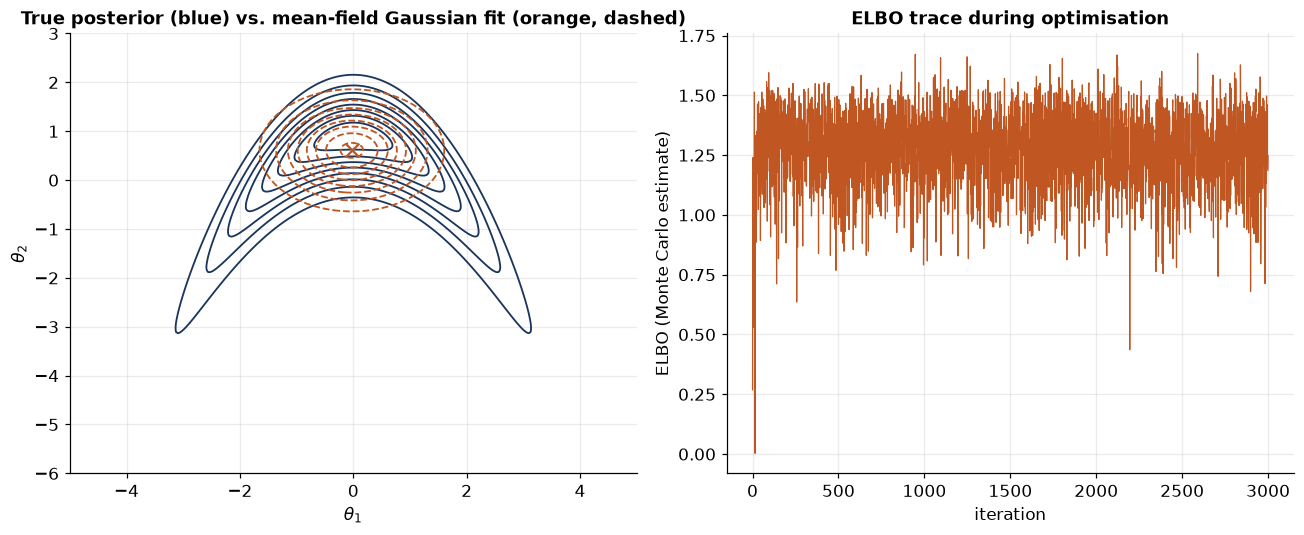

In [4]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].contour(T1, T2, Z_true, levels=10, colors=[PALETTE["true"]], linewidths=1.2)
Z_fit = (
    norm.pdf(T1, mu_fit[0], sigma_fit[0]) * norm.pdf(T2, mu_fit[1], sigma_fit[1])
)
axes[0].contour(T1, T2, Z_fit, levels=10, colors=[PALETTE["approx"]], linewidths=1.2,
                linestyles="--")
axes[0].set_title("True posterior (blue) vs. mean-field Gaussian fit (orange, dashed)")
axes[0].set_xlabel(r"$\theta_1$")
axes[0].set_ylabel(r"$\theta_2$")
axes[0].scatter(*mu_fit, color=PALETTE["approx"], marker="x", s=80, zorder=5)

axes[1].plot(elbo_trace, color=PALETTE["approx"], lw=0.8)
axes[1].set_title("ELBO trace during optimisation")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("ELBO (Monte Carlo estimate)")

fig.tight_layout()
save_fig(fig, "vi_true_vs_approx", NB_DIR)
plt.show()

## Takeaways

- The optimisation converges quickly and reliably (see the ELBO trace) — this is the
  chapter's point about speed: no long MCMC burn-in, no autocorrelated samples, just a
  gradient-ascent loop.
- But the fitted Gaussian visibly cannot bend around the banana: mean-field VI
  systematically **understates the posterior's true shape and correlation structure**,
  typically underestimating variance in some directions to keep the approximation
  concentrated where the true density is highest. This is exactly the "additional
  source of error" the chapter attributes to variational methods relative to (in
  principle exact, given enough time) MCMC sampling.
- The trade-off is real and symmetric: notebook 1's Metropolis–Hastings sampler would
  eventually trace out the true banana shape perfectly, but it needs many more
  evaluations to do so than this VI fit needed iterations. Blei, Kucukelbir &
  McAuliffe's description — "optimisation-based approximate Bayesian inference" —
  is a precise summary of what just happened.